# Retail Demand Forecasting

[![Dataset](https://img.shields.io/badge/Dataset-Kaggle%20Store%20Sales-20BEFF?logo=kaggle&logoColor=white)](https://www.kaggle.com/competitions/store-sales-time-series-forecasting)
[![Python](https://img.shields.io/badge/Python-3.10-3776AB?logo=python&logoColor=white)](https://www.python.org/)
[![LightGBM](https://img.shields.io/badge/Model-LightGBM-9ACD32?logo=lightgbm&logoColor=white)](https://lightgbm.readthedocs.io/)
[![MLflow](https://img.shields.io/badge/Tracking-MLflow-0194E2?logo=mlflow&logoColor=white)](https://mlflow.org/)
[![SHAP](https://img.shields.io/badge/Explainability-SHAP-FF6B6B)](https://shap.readthedocs.io/)
[![Streamlit](https://img.shields.io/badge/Deployment-Streamlit-FF4B4B?logo=streamlit&logoColor=white)](https://streamlit.io/)

### Goal
Create impactful features that improve forecasting accuracy by capturing past behavior, seasonal patterns, and demand trends in the data.

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/Demand Forecasting Project/'

print('Setup complete')

Mounted at /content/drive
Setup complete


## 2. Load Clean Panel

In [4]:
panel = pd.read_parquet(DATA_PATH + 'panel_clean.parquet')

print(f'Shape      : {panel.shape}')
print(f'Columns    : {panel.columns.tolist()}')
print(f'Date range : {panel["date"].min().date()} → {panel["date"].max().date()}')
panel.head(3)

Shape      : (3000888, 11)
Columns    : ['date', 'store_nbr', 'family', 'sales', 'onpromotion', 'city', 'state', 'type', 'cluster', 'dcoilwtico', 'is_holiday']
Date range : 2013-01-01 → 2017-08-15


,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,dcoilwtico,is_holiday
0,2013-01-01,1,AUTOMOTIVE,0.0000,0,Quito,Pichincha,D,13,93.1400,1
1,2013-01-01,1,BABY CARE,0.0000,0,Quito,Pichincha,D,13,93.1400,1
2,2013-01-01,1,BEAUTY,0.0000,0,Quito,Pichincha,D,13,93.1400,1


## 3. Calendar Features

In [7]:
# Sort Data Correctly for Lag and rolling features
panel = panel.sort_values(['store_nbr', 'family', 'date']).reset_index(drop=True)

panel['day_of_week']   = panel['date'].dt.dayofweek        # 0=Monday, 6=Sunday
panel['day_of_month']  = panel['date'].dt.day
panel['month']         = panel['date'].dt.month
panel['week_of_year']  = panel['date'].dt.isocalendar().week.astype(int)
panel['year']          = panel['date'].dt.year
panel['is_weekend']    = (panel['day_of_week'] >= 5).astype(int)
panel['quarter']       = panel['date'].dt.quarter

print('Calendar features added:')
cal_cols = ['day_of_week','day_of_month','month','week_of_year','year','is_weekend','quarter']
print(panel[['date'] + cal_cols].head(5).to_string(index=False))

Calendar features added:
      date  day_of_week  day_of_month  month  week_of_year  year  is_weekend  quarter
2013-01-01            1             1      1             1  2013           0        1
2013-01-02            2             2      1             1  2013           0        1
2013-01-03            3             3      1             1  2013           0        1
2013-01-04            4             4      1             1  2013           0        1
2013-01-05            5             5      1             1  2013           1        1


## 4. Lag Features

In [9]:
grp = panel.groupby(['store_nbr', 'family'])['sales']

for lag in [7, 14, 28]:
    panel[f'sales_lag_{lag}'] = grp.shift(lag)

lag_cols = ['sales_lag_7', 'sales_lag_14', 'sales_lag_28']
print(f'NaN rows expected for first 28 days: {panel["sales_lag_28"].isna().sum():,}')
panel[['date','store_nbr','family','sales'] + lag_cols].head(35).tail(5)

NaN rows expected for first 28 days: 49,896


,date,store_nbr,family,sales,sales_lag_7,sales_lag_14,sales_lag_28
30,2013-01-31,1,AUTOMOTIVE,0.0000,0.0000,1.0000,3.0000
31,2013-02-01,1,AUTOMOTIVE,3.0000,5.0000,0.0000,3.0000
32,2013-02-02,1,AUTOMOTIVE,0.0000,4.0000,5.0000,5.0000
33,2013-02-03,1,AUTOMOTIVE,0.0000,2.0000,3.0000,2.0000
34,2013-02-04,1,AUTOMOTIVE,5.0000,3.0000,1.0000,0.0000


## 5. Rolling Statistics

In [11]:
for window, stat in [(7, 'mean'), (28, 'mean'), (7, 'std')]:
    col_name = f'rolling_{stat}_{window}'
    rolled = grp.shift(1).rolling(window, min_periods=1)
    panel[col_name] = getattr(rolled, stat)()

roll_cols = ['rolling_mean_7', 'rolling_mean_28', 'rolling_std_7']
panel[['date','store_nbr','family','sales'] + roll_cols].head(35).tail(5)

,date,store_nbr,family,sales,rolling_mean_7,rolling_mean_28,rolling_std_7
30,2013-01-31,1,AUTOMOTIVE,0.0000,3.1429,2.3571,2.0354
31,2013-02-01,1,AUTOMOTIVE,3.0000,3.1429,2.2500,2.0354
32,2013-02-02,1,AUTOMOTIVE,0.0000,2.8571,2.2500,1.8645
33,2013-02-03,1,AUTOMOTIVE,0.0000,2.2857,2.0714,2.0587
34,2013-02-04,1,AUTOMOTIVE,5.0000,2.0000,2.0000,2.2361


## 6. Oil Price Features

In [13]:
panel['oil_lag1']        = panel.groupby(['store_nbr','family'])['dcoilwtico'].shift(1)
panel['oil_rolling7']    = panel.groupby(['store_nbr','family'])['dcoilwtico'].shift(1).rolling(7, min_periods=1).mean()

panel[['date','dcoilwtico','oil_lag1','oil_rolling7']].drop_duplicates('date').head(10)

,date,dcoilwtico,oil_lag1,oil_rolling7
0,2013-01-01,93.1400,NaN,NaN
1,2013-01-02,93.1400,93.1400,93.1400
2,2013-01-03,92.9700,93.1400,93.1400
3,2013-01-04,93.1200,92.9700,93.0833
4,2013-01-05,NaN,93.1200,93.0925
5,2013-01-06,NaN,NaN,93.0925
6,2013-01-07,93.2000,NaN,93.0925
7,2013-01-08,93.2100,93.2000,93.1140
8,2013-01-09,93.0800,93.2100,93.1280
9,2013-01-10,93.8100,93.0800,93.1160


## 7. Holiday Proximity Feature

In [14]:
holiday_dates = panel[panel['is_holiday'] == 1]['date'].unique()
holiday_dates = pd.to_datetime(sorted(holiday_dates))

def days_to_next_holiday(date):
    future = holiday_dates[holiday_dates >= date]
    if len(future) == 0:
        return 999
    return (future[0] - date).days

unique_dates = panel['date'].unique()
date_to_days = {d: days_to_next_holiday(d) for d in pd.to_datetime(unique_dates)}
panel['days_to_holiday'] = pd.to_datetime(panel['date']).map(date_to_days)

print(panel[panel['days_to_holiday'] < 5][['date','is_holiday','days_to_holiday']].drop_duplicates().head(10))

         date  is_holiday  days_to_holiday
0  2013-01-01           1                0
1  2013-01-02           0                3
2  2013-01-03           0                2
3  2013-01-04           0                1
4  2013-01-05           1                0
7  2013-01-08           0                4
8  2013-01-09           0                3
9  2013-01-10           0                2
10 2013-01-11           0                1
11 2013-01-12           1                0


## 8. Target Transformation — log1p(sales)

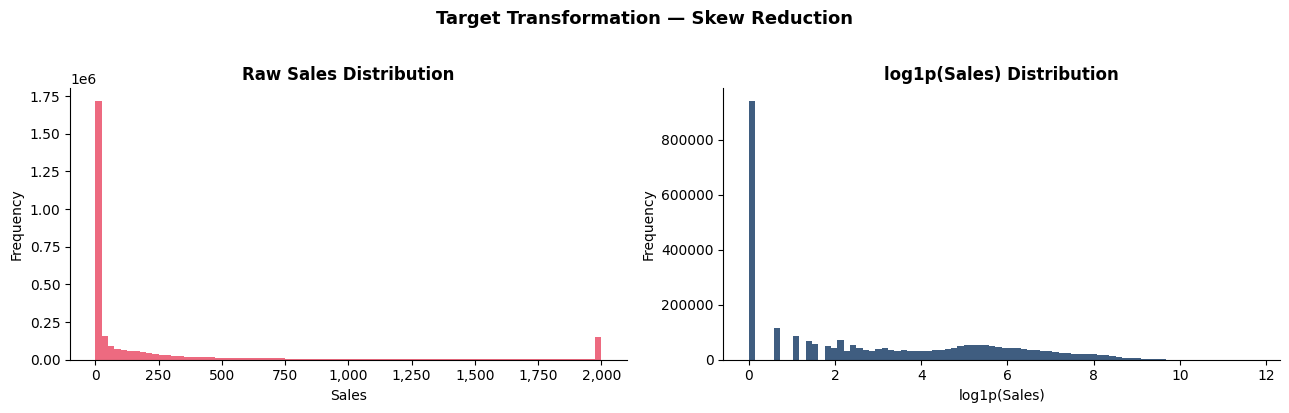

Skewness before: 7.36
Skewness after : 0.41


In [15]:
panel['sales_log'] = np.log1p(panel['sales'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(panel['sales'].clip(upper=2000), bins=80, color='#e94560', edgecolor='none', alpha=0.8)
axes[0].set_title('Raw Sales Distribution', fontweight='bold')
axes[0].set_xlabel('Sales')
axes[0].set_ylabel('Frequency')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].hist(panel['sales_log'], bins=80, color='#0f3460', edgecolor='none', alpha=0.8)
axes[1].set_title('log1p(Sales) Distribution', fontweight='bold')
axes[1].set_xlabel('log1p(Sales)')
axes[1].set_ylabel('Frequency')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Target Transformation — Skew Reduction', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(DATA_PATH + 'target_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Skewness before: {panel["sales"].skew():.2f}')
print(f'Skewness after : {panel["sales_log"].skew():.2f}')

## 9. Encode Categorical Columns

In [16]:
cat_cols = ['family', 'type', 'city', 'state']
for col in cat_cols:
    panel[col] = panel[col].astype('category')

print('Categorical columns encoded:')
for col in cat_cols:
    print(f'  {col}: {panel[col].nunique()} unique values')

Categorical columns encoded:
  family: 33 unique values
  type: 5 unique values
  city: 22 unique values
  state: 16 unique values


## 10. Final Feature Summary

In [17]:
feature_cols = [
    # Calendar
    'day_of_week', 'day_of_month', 'month', 'week_of_year',
    'year', 'is_weekend', 'quarter',
    # Lags
    'sales_lag_7', 'sales_lag_14', 'sales_lag_28',
    # Rolling
    'rolling_mean_7', 'rolling_mean_28', 'rolling_std_7',
    # Oil
    'oil_lag1', 'oil_rolling7',
    # Holiday
    'is_holiday', 'days_to_holiday',
    # Store
    'store_nbr', 'cluster',
    # Categoricals
    'family', 'type', 'city', 'state',
    # Promotion
    'onpromotion'
]

print(f'Total features : {len(feature_cols)}')
print(f'Target         : sales_log')
print(f'\nFeature list   :')
for i, f in enumerate(feature_cols, 1):
    print(f'  {i:02d}. {f}')

Total features : 24
Target         : sales_log

Feature list   :
  01. day_of_week
  02. day_of_month
  03. month
  04. week_of_year
  05. year
  06. is_weekend
  07. quarter
  08. sales_lag_7
  09. sales_lag_14
  10. sales_lag_28
  11. rolling_mean_7
  12. rolling_mean_28
  13. rolling_std_7
  14. oil_lag1
  15. oil_rolling7
  16. is_holiday
  17. days_to_holiday
  18. store_nbr
  19. cluster
  20. family
  21. type
  22. city
  23. state
  24. onpromotion


## 11. Drop Rows with NaN Lags & Save

In [18]:
before = len(panel)
panel = panel.dropna(subset=['sales_lag_28', 'rolling_mean_28']).reset_index(drop=True)
after = len(panel)

print(f'Rows before drop : {before:,}')
print(f'Rows dropped     : {before - after:,} ({(before-after)/before*100:.1f}%)')
print(f'Rows remaining   : {after:,}')

# Verify no NaNs in feature columns
nan_check = panel[feature_cols].isnull().sum()
print(f'\nNaN check (should all be 0):')
print(nan_check[nan_check > 0] if nan_check.sum() > 0 else 'All clean ✓')

Rows before drop : 3,000,888
Rows dropped     : 49,896 (1.7%)
Rows remaining   : 2,950,992

NaN check (should all be 0):
oil_lag1    842886
dtype: int64


In [20]:
output_path = DATA_PATH + 'panel_features.parquet'
panel.to_parquet(output_path, index=False)

# Verify
check = pd.read_parquet(output_path)
print(f'Saved and verified: {check.shape}')
print(f'File: {output_path}')

Saved and verified: (2950992, 28)
File: /content/drive/MyDrive/Colab Notebooks/Demand Forecasting Project/panel_features.parquet
